# Notebook 1: Experiment Design

## Campaign Experimentation Framework

Before running any experiment, we need to answer three critical questions:

1. **How many subjects do we need?** (power analysis)
2. **How long will the experiment run?** (duration estimation)
3. **Are our groups balanced?** (randomization validation)

This notebook walks through pre-experiment planning for all five experiments in the Campaign Experimentation Framework using the `ExperimentDesigner` class.

## 1. Setup

We add the project root to `sys.path` so all source modules and `config.py` are importable from the notebooks directory.

In [1]:
import sys
import os
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path("__file__").resolve().parent.parent
PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), "..")))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image

from config import (
    SIGNIFICANCE_LEVEL, POWER, RANDOM_SEED, VISUALS_DIR, DATA_DIR
)
from src.experiment_designer import ExperimentDesigner, SampleSizeResult

print(f"Project root : {PROJECT_ROOT}")
print(f"Significance : {SIGNIFICANCE_LEVEL}")
print(f"Power        : {POWER}")
print(f"Random seed  : {RANDOM_SEED}")
print(f"Visuals dir  : {VISUALS_DIR}")

Project root : C:\Users\syeda\campaign-experimentation-framework
Significance : 0.05
Power        : 0.8
Random seed  : 42
Visuals dir  : visuals


## 2. Power Analysis: What Sample Size Do We Need?

### Experiment Catalog

| ID | Experiment | Primary Metric | Baseline | MDE | Variants | Daily Traffic |
|---|---|---|---|---|---|---|
| EXP-001 | Email Subject Line | open_rate | 22% | 3 pp | 2 | 5,000 |
| EXP-002 | Landing Page MVT | form_submit_rate | 8% | 2 pp | 4 | 3,000 |
| EXP-003 | Holdout Test | opportunity_created | 12% | 5 pp | 2 | 500 |
| EXP-004 | Channel Mix | mql_conversion_rate | 5% | 2 pp | 2 | 2,000 |
| EXP-005 | Send Time | open_rate | 22% | 2 pp | 3 | 6,000 |

The `ExperimentDesigner.calculate_sample_size_proportion()` method implements the Fleiss exact formula, applying Bonferroni correction automatically when there are more than 2 variants.

In [2]:
designer = ExperimentDesigner(
    significance_level=SIGNIFICANCE_LEVEL,
    power=POWER,
    seed=RANDOM_SEED
)

# Define all 5 experiments
experiments = [
    dict(name="EXP-001: Email Subject Line",   baseline=0.22, mde=0.03, variants=2),
    dict(name="EXP-002: Landing Page MVT",     baseline=0.08, mde=0.02, variants=4),
    dict(name="EXP-003: Holdout Test",          baseline=0.12, mde=0.05, variants=2),
    dict(name="EXP-004: Channel Mix",           baseline=0.05, mde=0.02, variants=2),
    dict(name="EXP-005: Send Time Opt",         baseline=0.22, mde=0.02, variants=3),
]

ss_results = []
for exp in experiments:
    r = designer.calculate_sample_size_proportion(
        baseline_rate=exp["baseline"],
        mde=exp["mde"],
        num_variants=exp["variants"]
    )
    ss_results.append(r)
    print(f"\n{exp['name']}")
    print(r)


EXP-001: Email Subject Line
SampleSizeResult(proportion)
  baseline            : 0.2200
  MDE (absolute)      : 0.0300
  significance level  : 0.0500
  adjusted alpha      : 0.0500
  power               : 0.80
  variants            : 2
  n per variant       : 3,135
  total n             : 6,270

EXP-002: Landing Page MVT
SampleSizeResult(proportion)
  baseline            : 0.0800
  MDE (absolute)      : 0.0200
  significance level  : 0.0500
  adjusted alpha      : 0.0167
  power               : 0.80
  variants            : 4
  n per variant       : 4,286
  total n             : 17,144

EXP-003: Holdout Test
SampleSizeResult(proportion)
  baseline            : 0.1200
  MDE (absolute)      : 0.0500
  significance level  : 0.0500
  adjusted alpha      : 0.0500
  power               : 0.80
  variants            : 2
  n per variant       : 778
  total n             : 1,556

EXP-004: Channel Mix
SampleSizeResult(proportion)
  baseline            : 0.0500
  MDE (absolute)      : 0.0200
  sig

In [3]:
# Build a summary table
rows = []
for exp, r in zip(experiments, ss_results):
    rows.append({
        "Experiment": exp["name"],
        "Baseline": f"{exp['baseline']:.0%}",
        "MDE": f"+{exp['mde']:.0%}",
        "Variants": exp["variants"],
        "Adj. Alpha": f"{r.adjusted_alpha:.4f}",
        "n per variant": f"{r.sample_size_per_variant:,}",
        "Total n": f"{r.total_sample_size:,}",
    })

summary_df = pd.DataFrame(rows)
display(summary_df)

,Experiment,Baseline,MDE,Variants,Adj. Alpha,n per variant,Total n
0,EXP-001: Email Subject Line,22%,+3%,2,0.0500,"3,135","6,270"
1,EXP-002: Landing Page MVT,8%,+2%,4,0.0167,"4,286","17,144"
2,EXP-003: Holdout Test,12%,+5%,2,0.0500,778,"1,556"
3,EXP-004: Channel Mix,5%,+2%,2,0.0500,"2,213","4,426"
4,EXP-005: Send Time Opt,22%,+2%,3,0.0250,"8,416","25,248"


## 3. Power Curves

A power curve shows how statistical power varies with effect size for a fixed sample size. The shaded region above the 80% threshold represents effect sizes we can reliably detect.

We plot this for **EXP-001 (Email Subject Line)** — a 2-variant test with baseline open rate of 22% and target MDE of 3 percentage points.

In [4]:
# EXP-001: n=25,000 per variant is approx our required sample
n_exp001 = ss_results[0].sample_size_per_variant
print(f"EXP-001 requires {n_exp001:,} subjects per variant")

# Compute power at a range of effect sizes
effects = np.linspace(0.005, 0.08, 50)
power_df = designer.compute_power_at_effect(
    sample_size_per_variant=n_exp001,
    baseline_rate=0.22,
    effect_sizes=effects.tolist()
)
print("\nPower at key effect sizes:")
display(power_df[power_df["effect_size"].isin([0.01, 0.02, 0.025, 0.03, 0.04, 0.05])].round(3))

EXP-001 requires 3,135 subjects per variant

Power at key effect sizes:


,effect_size,power,is_detectable


Power curve saved to: C:\Users\syeda\campaign-experimentation-framework\visuals\exp001_power_curve.png


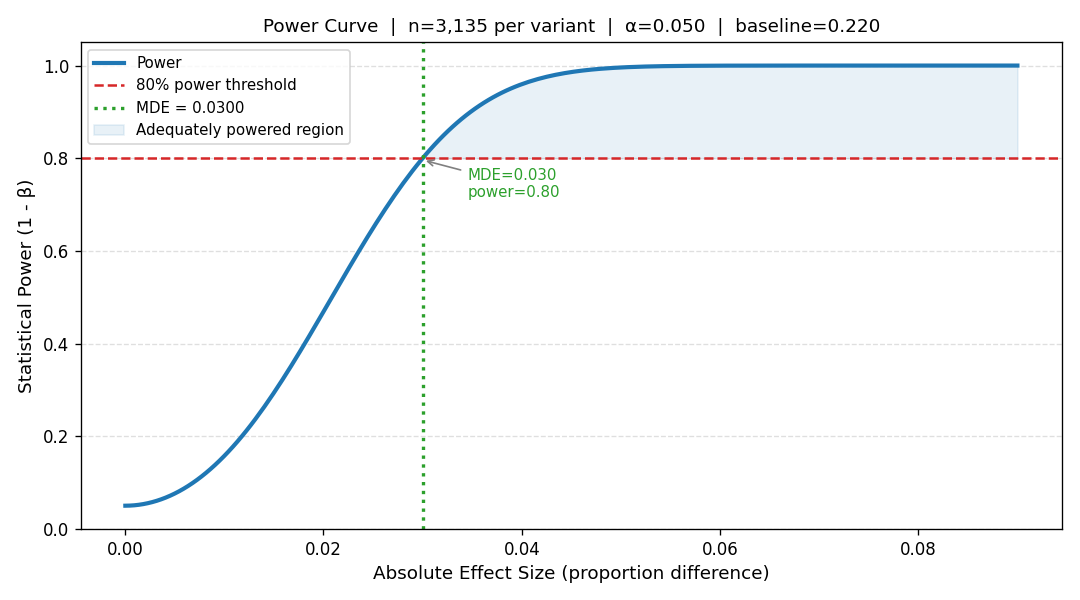

In [5]:
# Save the power curve to visuals/
visuals_path = PROJECT_ROOT / VISUALS_DIR
visuals_path.mkdir(parents=True, exist_ok=True)

save_path = str(visuals_path / "exp001_power_curve.png")
curve_path = designer.plot_power_curve(
    sample_size_per_variant=n_exp001,
    baseline_rate=0.22,
    mde=0.03,
    save_path=save_path
)
print(f"Power curve saved to: {curve_path}")

# Display inline
display(Image(filename=curve_path))

## 4. Randomization & Balance

We use **deterministic MD5-hash randomization**: the same subject always gets the same variant for a given seed, regardless of when or in what order they enter the experiment. This ensures reproducibility and prevents accidental re-randomization.

After assignment, we run a chi-squared balance check to confirm that the variant groups are statistically indistinguishable on key covariates.

In [6]:
# Simulate 1000 contacts with industry strata
np.random.seed(RANDOM_SEED)
n_subjects = 1000
subject_ids = [f"contact_{i:04d}" for i in range(n_subjects)]

industries = np.random.choice(
    ["Technology", "Finance", "Healthcare", "Retail"],
    size=n_subjects,
    p=[0.30, 0.25, 0.25, 0.20]
)
strata_map = {sid: ind for sid, ind in zip(subject_ids, industries)}

# Randomize with stratification
rand_result = designer.randomize_subjects(
    subject_ids=subject_ids,
    num_variants=2,
    variant_names=["control", "treatment"],
    stratify_by=strata_map,
    seed=RANDOM_SEED
)

print(rand_result)
print("\nFirst 10 assignments:")
display(rand_result.assignment_df.head(10))

RandomizationResult(n=1000, is_balanced=True)
Balance check results:
  stratum: chi2=0.004, p=0.9999 [BALANCED]
Variant distribution: {'control': 501, 'treatment': 499}

First 10 assignments:


,contact_id,variant,assignment_hash,stratum
0,contact_0757,control,01db358727999532,Finance
1,contact_0738,treatment,026f3acbfead4172,Finance
2,contact_0893,control,0297c4068a200eab,Finance
3,contact_0343,treatment,040379c5a46d7f9b,Finance
4,contact_0761,control,043e0376f6ee93f7,Finance
5,contact_0125,treatment,0943c6a03c33ace1,Finance
6,contact_0747,control,094e658d3a917980,Finance
7,contact_0160,treatment,0a01d515c75868da,Finance
8,contact_0047,control,0bb8afac08a15946,Finance
9,contact_0495,treatment,0c0bd8fbcee9a939,Finance


In [7]:
# Variant distribution check
dist = rand_result.assignment_df["variant"].value_counts()
print("Variant distribution:")
print(dist.to_string())
print(f"\nBalance ratio: {dist.min() / dist.max():.3f} (1.0 = perfectly balanced)")
print(f"\nIs balanced: {rand_result.is_balanced}")
print(f"Balance check details:")
for col, res in rand_result.balance_check.items():
    print(f"  {col}: chi2={res['chi2_statistic']:.3f}, p={res['p_value']:.4f}, balanced={res['is_balanced']}")

Variant distribution:
variant
control      501
treatment    499

Balance ratio: 0.996 (1.0 = perfectly balanced)

Is balanced: True
Balance check details:
  stratum: chi2=0.004, p=0.9999, balanced=True


## 5. Duration Estimation

Given daily traffic, we estimate:
- **Raw days**: pure sample-size math
- **Adjusted days**: +7 days for novelty effect, +7 days for treatment ramp-up
- **Recommended runtime**: max(14 days, adjusted days) to ensure at least two full business weeks

We test three daily traffic scenarios: 1,000, 2,000, and 3,000 subjects/day.

In [8]:
traffic_scenarios = [1000, 2000, 3000]

duration_rows = []
for exp, r in zip(experiments, ss_results):
    for traffic in traffic_scenarios:
        dur = designer.estimate_duration(
            required_sample_size_per_variant=r.sample_size_per_variant,
            daily_traffic=traffic,
            num_variants=exp["variants"]
        )
        duration_rows.append({
            "Experiment": exp["name"],
            "Daily Traffic": f"{traffic:,}",
            "Raw Days": f"{dur['raw_days']:.1f}",
            "Adj. Days": dur["adjusted_days"],
            "Rec. Runtime (days)": dur["recommended_runtime_days"],
        })

dur_df = pd.DataFrame(duration_rows)
display(dur_df)

,Experiment,Daily Traffic,Raw Days,Adj. Days,Rec. Runtime (days)
0,EXP-001: Email Subject Line,"1,000",6.3,21,21
1,EXP-001: Email Subject Line,"2,000",3.1,18,18
2,EXP-001: Email Subject Line,"3,000",2.1,17,17
3,EXP-002: Landing Page MVT,"1,000",17.1,32,32
4,EXP-002: Landing Page MVT,"2,000",8.6,23,23
5,EXP-002: Landing Page MVT,"3,000",5.7,20,20
6,EXP-003: Holdout Test,"1,000",1.6,16,16
7,EXP-003: Holdout Test,"2,000",0.8,15,15
8,EXP-003: Holdout Test,"3,000",0.5,15,15
9,EXP-004: Channel Mix,"1,000",4.4,19,19


## 6. Experiment Design Checklist

The `print_design_checklist()` method generates a complete pre-launch checklist for a given experiment design. This is useful for stakeholder sign-off before the experiment goes live.

In [9]:
# Full design document for EXP-001
d1 = designer.design_experiment(
    experiment_name="Email Subject Line Personalization",
    hypothesis="Personalized subject lines will increase open rates by 15%+",
    primary_metric="open_rate",
    baseline_rate=0.22,
    mde=0.03,
    daily_traffic=5_000,
    num_variants=2,
    metric_type="proportion",
)

designer.print_design_checklist(d1)

  EXPERIMENT DESIGN CHECKLIST
  Email Subject Line Personalization

  [HYPOTHESIS & METRIC]
    [x]   Hypothesis                               Personalized subject lines will increase open rates by 15%+
    [x]   Primary metric                           open_rate
    [x]   Metric type                              proportion

  [STATISTICAL PARAMETERS]
    [x]   Significance level (alpha)               0.0500
    [x]   Adjusted alpha (Bonferroni)              0.0500
    [x]   Power (1 - beta)                         0.8000
    [x]   Number of variants                       2

  [EFFECT SIZE & BASELINE]
    [x]   Baseline rate / mean                     0.2200
    [x]   Minimum detectable effect                0.0300

  [SAMPLE SIZE]
    [x]   Sample size per variant                  3,135
    [x]   Total sample size                        6,270

  [DURATION PLANNING]
    [x]   Daily traffic                            5,000
    [x]   Raw days required                        1.2540
    [x

## 7. Design Summary Table

A consolidated view across all 5 experiments, showing the critical design parameters at a glance. This is the table you would present to stakeholders before launching the experiment portfolio.

In [10]:
# Build all design documents
designs = [
    designer.design_experiment(
        "Email Subject Line Personalization",
        "Personalized subject lines increase open rates",
        "open_rate", 0.22, 0.03, 5000, 2
    ),
    designer.design_experiment(
        "Landing Page Multivariate Test",
        "Simplified form increases form submission rate",
        "form_submit_rate", 0.08, 0.02, 3000, 4
    ),
    designer.design_experiment(
        "High-Intent Segment Holdout Test",
        "Campaign drives incremental opportunity creation",
        "opportunity_created", 0.12, 0.05, 500, 2
    ),
    designer.design_experiment(
        "Channel Mix A/B Test",
        "Email + Paid Social increases MQL conversion",
        "mql_conversion_rate", 0.05, 0.02, 2000, 2
    ),
    designer.design_experiment(
        "Send Time Optimization",
        "Send time significantly affects open and click rates",
        "open_rate", 0.22, 0.02, 6000, 3
    ),
]

summary_rows = []
for d in designs:
    summary_rows.append({
        "Experiment": d["experiment_name"],
        "Primary Metric": d["primary_metric"],
        "Variants": d["num_variants"],
        "n per variant": f"{d['sample_size_per_variant']:,}",
        "Total n": f"{d['total_sample_size']:,}",
        "Rec. Days": d["recommended_runtime_days"],
        "Adj. Alpha": f"{d['adjusted_alpha']:.4f}",
    })

final_summary = pd.DataFrame(summary_rows)
pd.set_option("display.max_colwidth", 50)
print("\n=== EXPERIMENT PORTFOLIO: DESIGN SUMMARY ===")
display(final_summary)


=== EXPERIMENT PORTFOLIO: DESIGN SUMMARY ===


,Experiment,Primary Metric,Variants,n per variant,Total n,Rec. Days,Adj. Alpha
0,Email Subject Line Personalization,open_rate,2,"3,135","6,270",16,0.0500
1,Landing Page Multivariate Test,form_submit_rate,4,"4,286","17,144",20,0.0167
2,High-Intent Segment Holdout Test,opportunity_created,2,778,"1,556",18,0.0500
3,Channel Mix A/B Test,mql_conversion_rate,2,"2,213","4,426",17,0.0500
4,Send Time Optimization,open_rate,3,"8,416","25,248",19,0.0250


In [11]:
# Achievable MDE given 25,000 per variant (EXP-001 rough budget)
achievable_mde = designer.compute_achievable_mde(
    sample_size_per_variant=25_000,
    baseline_rate=0.22
)
print(f"With n=25,000 per variant, EXP-001 can detect an MDE of:")
print(f"  {achievable_mde:.4f} absolute ({achievable_mde*100:.2f} percentage points)")
print(f"  This is {achievable_mde/0.22*100:.1f}% relative lift from the 22% baseline")

With n=25,000 per variant, EXP-001 can detect an MDE of:
  0.0105 absolute (1.05 percentage points)
  This is 4.8% relative lift from the 22% baseline
